# RESULTS ANALYSIS

/tmp/ipykernel_181/613237833.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Cityscapes (ID)", "COCO (OOD)"])


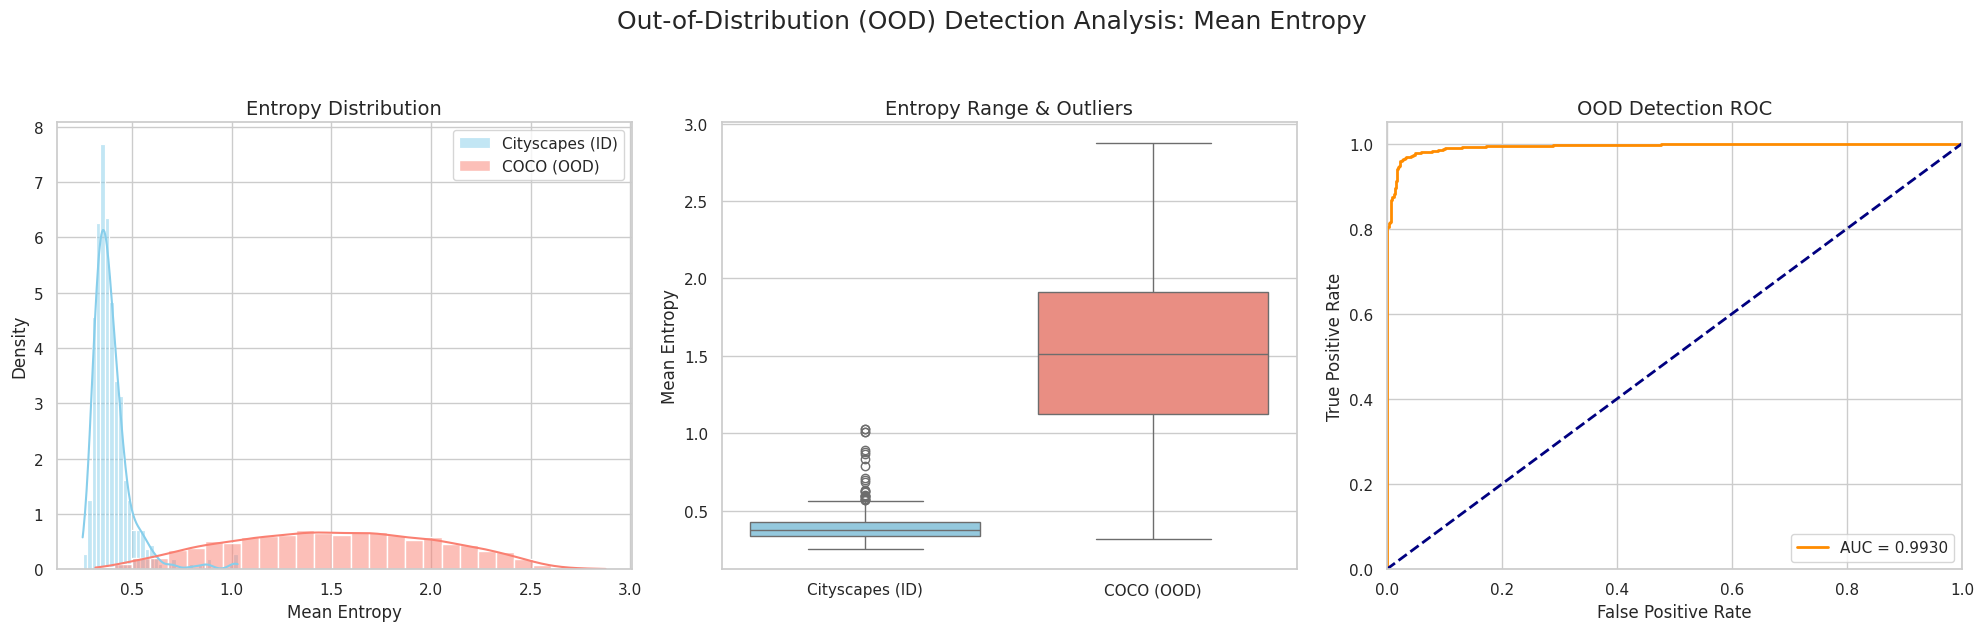

Suggested Entropy Threshold: 0.6290
At this threshold: True Positive Rate = 0.9626, False Positive Rate = 0.0258


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from pathlib import Path

DATA_FILE = "/content/entropy_data.npz"


data = np.load(DATA_FILE)
id_scores, id_dist = data['id_entropy'], data['id_dist']
ood_scores, ood_dist = data['ood_entropy'], data['ood_dist']

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# PLOT ENTROPY INFORMATION
sns.histplot(id_scores, kde=True, color="skyblue", label="Cityscapes (ID)",
              stat="density", alpha=0.5, ax=axes[0])
sns.histplot(ood_scores, kde=True, color="salmon", label="COCO (OOD)",
              stat="density", alpha=0.5, ax=axes[0])
axes[0].set_title("Entropy Distribution", fontsize=14)
axes[0].set_xlabel("Mean Entropy")
axes[0].legend()

sns.boxplot(data=[id_scores, ood_scores], palette=["skyblue", "salmon"], ax=axes[1])
axes[1].set_xticklabels(["Cityscapes (ID)", "COCO (OOD)"])
axes[1].set_title("Entropy Range & Outliers", fontsize=14)
axes[1].set_ylabel("Mean Entropy")

y_true = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])
y_scores = np.concatenate([id_scores, ood_scores])
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('OOD Detection ROC', fontsize=14)
axes[2].legend(loc="lower right")

plt.suptitle("Out-of-Distribution (OOD) Detection Analysis: Mean Entropy", fontsize=18, y=1.05)
plt.tight_layout()

plt.savefig("ood_analysis_combined.png", bbox_inches='tight')
plt.show()

# Calculate and print the "Optimal" Threshold (Youden's J statistic)
idx = np.argmax(tpr - fpr)
best_threshold = thresholds[idx]
print(f"Suggested Entropy Threshold: {best_threshold:.4f}")
print(f"At this threshold: True Positive Rate = {tpr[idx]:.4f}, False Positive Rate = {fpr[idx]:.4f}")

/tmp/ipykernel_181/4113159560.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Cityscapes (ID)", "COCO (OOD)"])


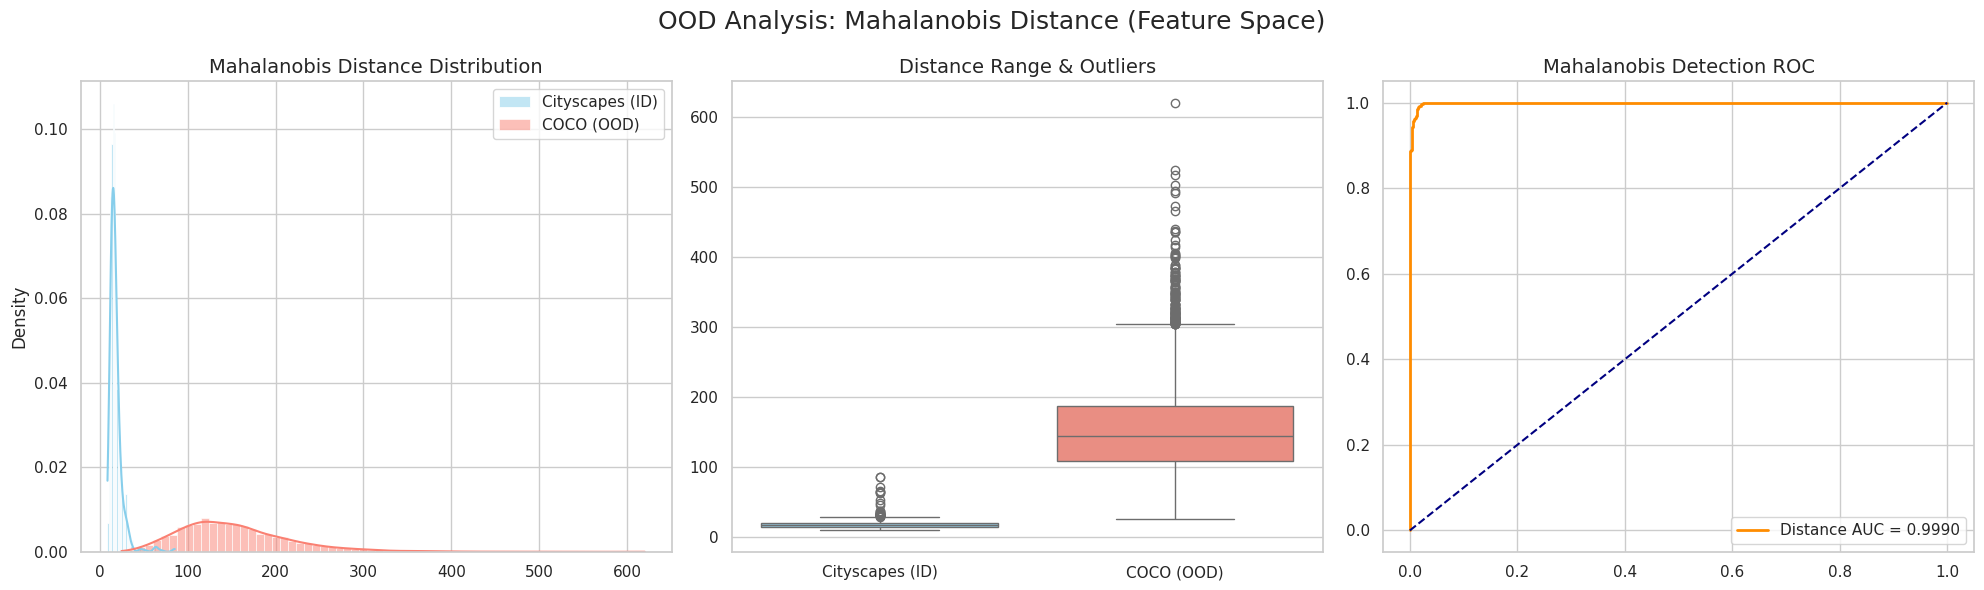

In [23]:
# PLOT MAHALANOBIS DISTANCE INFORMATION

sns.set_theme(style="whitegrid")

fig1, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(id_dist, kde=True, color="skyblue", label="Cityscapes (ID)", stat="density", ax=axes[0])
sns.histplot(ood_dist, kde=True, color="salmon", label="COCO (OOD)", stat="density", ax=axes[0])
axes[0].set_title("Mahalanobis Distance Distribution", fontsize=14)
axes[0].legend()

# Boxplot
sns.boxplot(data=[id_dist, ood_dist], palette=["skyblue", "salmon"], ax=axes[1])
axes[1].set_xticklabels(["Cityscapes (ID)", "COCO (OOD)"])
axes[1].set_title("Distance Range & Outliers", fontsize=14)

# ROC Curve
y_true = np.concatenate([np.zeros(len(id_dist)), np.ones(len(ood_dist))])
y_scores = np.concatenate([id_dist, ood_dist])
fpr, tpr, _ = roc_curve(y_true, y_scores)
axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'Distance AUC = {auc(fpr, tpr):.4f}')
axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[2].set_title("Mahalanobis Detection ROC", fontsize=14)
axes[2].legend(loc="lower right")

plt.suptitle("OOD Analysis: Mahalanobis Distance (Feature Space)", fontsize=18)
plt.tight_layout()
plt.show()

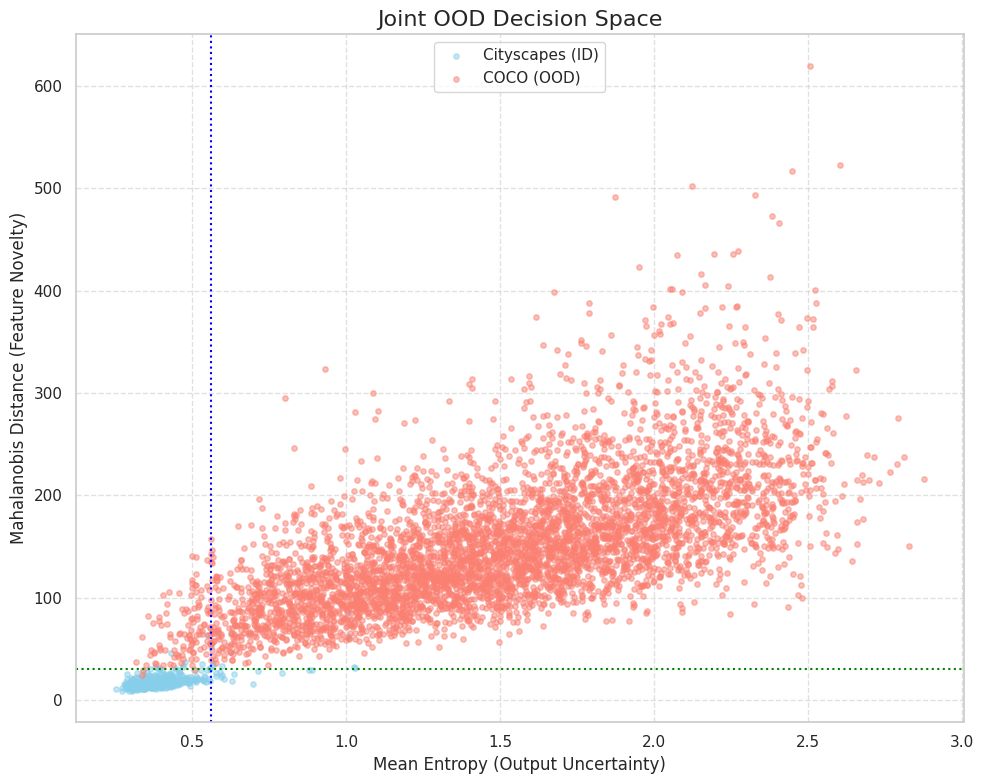

In [24]:
plt.figure(figsize=(10, 8))

# Plot ID points
plt.scatter(id_scores, id_dist, color='skyblue', alpha=0.5, s=15, label='Cityscapes (ID)')
# Plot OOD points
plt.scatter(ood_scores, ood_dist, color='salmon', alpha=0.5, s=15, label='COCO (OOD)')

plt.xlabel("Mean Entropy (Output Uncertainty)")
plt.ylabel("Mahalanobis Distance (Feature Novelty)")
plt.title("Joint OOD Decision Space", fontsize=16)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.axvline(x=np.percentile(id_scores, 95), color='blue', linestyle=':', label='95% ID Entropy')
plt.axhline(y=np.percentile(id_dist, 95), color='green', linestyle=':', label='95% ID Distance')

plt.tight_layout()
plt.savefig("joint_ood_scatter.png")
plt.show()

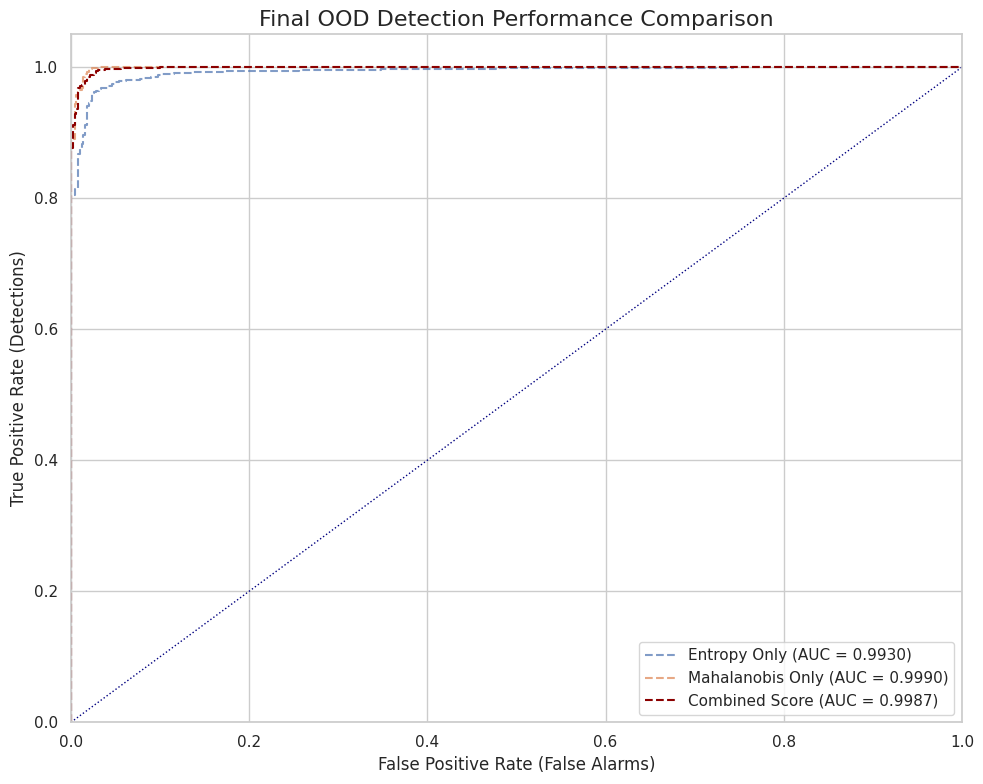

Improvement over Entropy: 0.005661


In [27]:
id_ent_mean = np.mean(id_scores)
id_ent_std = np.std(id_scores)

id_dist_mean = np.mean(id_dist)
id_dist_std = np.std(id_dist)

#Normalize ID data (will now have Mean=0, Std=1)
id_z_ent = (id_scores - id_ent_mean) / id_ent_std
id_z_dist = (id_dist - id_dist_mean) / id_dist_std

# Normalize OOD data using the ID baseline
ood_z_ent = (ood_scores - id_ent_mean) / id_ent_std
ood_z_dist = (ood_dist - id_dist_mean) / id_dist_std

#Combine
id_combined = id_z_ent + id_z_dist
ood_combined = ood_z_ent + ood_z_dist

def get_roc_data(id_scores, ood_scores):
    y_true = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])
    y_scores = np.concatenate([id_scores, ood_scores])
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    return fpr, tpr, auc(fpr, tpr)

fpr_e, tpr_e, auc_e = get_roc_data(id_scores, ood_scores)
fpr_d, tpr_d, auc_d = get_roc_data(id_dist, ood_dist)
fpr_c, tpr_c, auc_c = get_roc_data(id_combined, ood_combined)

# --- Visualization ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

plt.plot(fpr_e, tpr_e, label=f'Entropy Only (AUC = {auc_e:.4f})', linestyle='--', alpha=0.7)
plt.plot(fpr_d, tpr_d, label=f'Mahalanobis Only (AUC = {auc_d:.4f})', linestyle='--', alpha=0.7)
plt.plot(fpr_c, tpr_c, label=f'Combined Score (AUC = {auc_c:.4f})', linestyle='--', color='darkred')

plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle=':')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Detections)')
plt.title('Final OOD Detection Performance Comparison', fontsize=16)
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig("final_ood_comparison.png")
plt.show()

print(f"Improvement over Entropy: {auc_c - auc_e:.6f}")